# Exchange Rate Forecasting
## dataset from ts-arena/exchange_rate at HuggingFace
#### The dataset is a time series data of 8 currencies against the USD for 26 years(1990-2016)
#### Total samples :7588
#### Frequency:1 day
#### Train split: 5311
#### Test split: 1518
#### Validation split: 759

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import pandas as pd
dataset=load_dataset("ts-arena/exchange_rate")

print(dataset)



/Users/akarn/Documents/Exchange_curr_pred/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['0', '1', '2', '3', '4', '5', '6', 'OT', 'timestamp_idx'],
        num_rows: 5311
    })
    validation: Dataset({
        features: ['0', '1', '2', '3', '4', '5', '6', 'OT', 'timestamp_idx'],
        num_rows: 759
    })
    test: Dataset({
        features: ['0', '1', '2', '3', '4', '5', '6', 'OT', 'timestamp_idx'],
        num_rows: 1518
    })
})


In [2]:
df_train=dataset['train'].to_pandas()
df_test=dataset['test'].to_pandas()
df_val=dataset['validation'].to_pandas()

In [3]:
df_train.head()

,0,1,2,3,4,5,6,OT,timestamp_idx
0,0.606785,-0.361671,0.735367,-1.164374,2.85189,-1.861369,-1.820047,-0.124081,0
1,0.570900,-0.367639,0.729630,-1.170907,2.85189,-1.838665,-1.847258,-0.113588,1
2,0.618423,-0.252456,0.728914,-1.027468,2.85189,-1.736953,-1.805130,-0.078960,2
3,0.611634,-0.206502,0.738951,-1.007285,2.85189,-1.756932,-1.849738,-0.082108,3
4,0.600966,-0.111013,0.738235,-0.953372,2.85189,-1.768738,-1.785181,-0.066368,4


In [4]:
df_test.head()

,0,1,2,3,4,5,6,OT,timestamp_idx
0,2.932966,-0.386660,2.284381,3.009448,0.867502,3.459447,3.444769,2.247401,0
1,2.948076,-0.357297,2.207398,3.092555,0.877601,3.438560,3.467199,2.190758,1
2,3.049320,-0.334218,2.272394,3.137313,0.886589,3.457630,3.515654,2.282028,2
3,3.064168,-0.347205,2.253201,3.140460,0.889535,3.391336,3.495937,2.275648,3
4,3.005783,-0.424341,2.140315,3.074762,0.887163,3.376806,3.458159,2.222133,4


In [5]:
df_val.head()

,0,1,2,3,4,5,6,OT,timestamp_idx
0,1.225837,-1.296029,1.762672,1.094348,0.370287,1.831145,1.553923,0.883164,0
1,1.332851,-1.176363,1.778088,1.146845,0.369445,1.825696,1.608091,0.960699,1
2,1.354440,-1.137129,1.812542,1.216388,0.369445,1.856573,1.641359,0.965788,2
3,1.380500,-1.128482,1.842089,1.256114,0.369445,1.869287,1.632103,0.986229,3
4,1.389229,-1.134903,1.799020,1.373218,0.372735,1.922868,1.645996,1.028485,4


In [6]:

currency_cols = [str(i) for i in range(7)]

rename_map = {
    col: f"USD_vs_Curr{int(col)+1}"
    for col in currency_cols
}

for df in [df_train, df_val, df_test]:
    df.rename(columns=rename_map, inplace=True)

print(df_train.columns)
print(df_test.columns)
print(df_val.columns)

Index(['USD_vs_Curr1', 'USD_vs_Curr2', 'USD_vs_Curr3', 'USD_vs_Curr4',
       'USD_vs_Curr5', 'USD_vs_Curr6', 'USD_vs_Curr7', 'OT', 'timestamp_idx'],
      dtype='str')
Index(['USD_vs_Curr1', 'USD_vs_Curr2', 'USD_vs_Curr3', 'USD_vs_Curr4',
       'USD_vs_Curr5', 'USD_vs_Curr6', 'USD_vs_Curr7', 'OT', 'timestamp_idx'],
      dtype='str')
Index(['USD_vs_Curr1', 'USD_vs_Curr2', 'USD_vs_Curr3', 'USD_vs_Curr4',
       'USD_vs_Curr5', 'USD_vs_Curr6', 'USD_vs_Curr7', 'OT', 'timestamp_idx'],
      dtype='str')


In [7]:
df=pd.concat([df_train,df_val,df_test],ignore_index=True)

In [8]:
df.tail()

,USD_vs_Curr1,USD_vs_Curr2,USD_vs_Curr3,USD_vs_Curr4,USD_vs_Curr5,USD_vs_Curr6,USD_vs_Curr7,OT,timestamp_idx
7583,-0.043080,-2.682078,-0.464422,2.047593,0.268273,-0.352033,1.110884,0.902640,1513
7584,-0.010638,-2.674534,-0.428972,2.117643,0.270798,-0.265760,1.141850,0.953585,1514
7585,0.002532,-2.610963,-0.390056,2.186028,0.279748,-0.295729,1.162177,0.956124,1515
7586,-0.020472,-2.612192,-0.400227,2.146790,0.279595,-0.302086,1.153604,0.921979,1516
7587,-0.020472,-2.612192,-0.400227,2.146790,0.279595,-0.302086,1.153604,0.921979,1517


In [9]:
df_train.describe()

,USD_vs_Curr1,USD_vs_Curr2,USD_vs_Curr3,USD_vs_Curr4,USD_vs_Curr5,USD_vs_Curr6,USD_vs_Curr7,OT,timestamp_idx
count,5.311000e+03,5.311000e+03,5.311000e+03,5311.000000,5.311000e+03,5311.000000,5.311000e+03,5.311000e+03,5311.000000
mean,-2.873054e-08,1.149222e-08,-1.149222e-08,0.000000,-3.447665e-08,0.000000,-5.746108e-09,-1.149222e-08,2655.000000
std,1.000094e+00,1.000094e+00,1.000094e+00,1.000094,1.000094e+00,1.000094,1.000094e+00,1.000094e+00,1533.297971
min,-2.324163e+00,-1.786166e+00,-1.612920e+00,-1.983000,-1.047729e+00,-2.391725,-1.849738e+00,-2.221123e+00,0.000000
25%,-6.525500e-01,-7.650247e-01,-7.928607e-01,-0.789243,-6.088446e-01,-0.631287,-8.212811e-01,-6.886171e-01,1327.500000
50%,1.902298e-01,-2.187425e-01,-2.229339e-01,0.037868,-6.066260e-01,-0.104110,-2.382726e-01,4.240859e-03,2655.000000
75%,5.495632e-01,7.696171e-01,7.558249e-01,0.673665,3.706311e-01,0.539310,9.784989e-01,8.491665e-01,3982.500000
max,2.473281e+00,2.610416e+00,2.955284e+00,2.469653,2.852769e+00,3.123433,2.082295e+00,2.219583e+00,5310.000000


In [10]:
df_train.isnull().sum()

USD_vs_Curr1     0
USD_vs_Curr2     0
USD_vs_Curr3     0
USD_vs_Curr4     0
USD_vs_Curr5     0
USD_vs_Curr6     0
USD_vs_Curr7     0
OT               0
timestamp_idx    0
dtype: int64

In [11]:
df_test.describe()

,USD_vs_Curr1,USD_vs_Curr2,USD_vs_Curr3,USD_vs_Curr4,USD_vs_Curr5,USD_vs_Curr6,USD_vs_Curr7,OT,timestamp_idx
count,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000
mean,1.232007,-0.862259,0.719797,2.890127,0.843241,0.494002,2.441934,1.674639,758.500000
std,1.064675,0.707133,0.916136,0.408368,0.213424,0.914868,0.690067,0.747720,438.353168
min,-0.359245,-2.745703,-0.968869,2.020321,0.267776,-0.842431,1.110884,0.213339,0.000000
25%,0.272221,-1.138245,-0.181457,2.573867,0.692354,-0.406976,1.869268,0.992643,379.250000
50%,1.239502,-0.756001,0.877593,2.870123,0.920843,0.643747,2.506913,1.806831,758.500000
75%,2.042384,-0.373315,1.585307,3.205414,0.996444,0.934807,3.092451,2.349148,1137.750000
max,3.441298,0.266215,2.284381,4.008609,3.873632,3.459447,3.515654,2.912441,1517.000000


In [12]:
df_test.isnull().sum()

USD_vs_Curr1     0
USD_vs_Curr2     0
USD_vs_Curr3     0
USD_vs_Curr4     0
USD_vs_Curr5     0
USD_vs_Curr6     0
USD_vs_Curr7     0
OT               0
timestamp_idx    0
dtype: int64

In [13]:
df_val.describe()

,USD_vs_Curr1,USD_vs_Curr2,USD_vs_Curr3,USD_vs_Curr4,USD_vs_Curr5,USD_vs_Curr6,USD_vs_Curr7,OT,timestamp_idx
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,2.775513,-0.512700,2.060402,3.039582,0.665057,3.143588,2.827632,1.853225,379.000000
std,0.542511,0.212995,0.250118,0.768972,0.147853,0.431299,0.482862,0.423652,219.248717
min,1.122896,-1.296029,1.481717,1.094348,0.369445,1.825696,1.553923,0.868747,0.000000
25%,2.553226,-0.655997,1.866556,2.593390,0.533960,2.860526,2.579117,1.551395,189.500000
50%,2.888099,-0.511666,2.077811,2.979392,0.685584,3.154311,2.880542,1.889875,379.000000
75%,3.167536,-0.350081,2.232941,3.343043,0.792647,3.509395,3.167904,2.217243,568.500000
max,3.681591,-0.005856,2.658131,5.913158,0.875382,3.918061,3.698757,2.861255,758.000000


In [14]:
df_val.isnull().sum()

USD_vs_Curr1     0
USD_vs_Curr2     0
USD_vs_Curr3     0
USD_vs_Curr4     0
USD_vs_Curr5     0
USD_vs_Curr6     0
USD_vs_Curr7     0
OT               0
timestamp_idx    0
dtype: int64

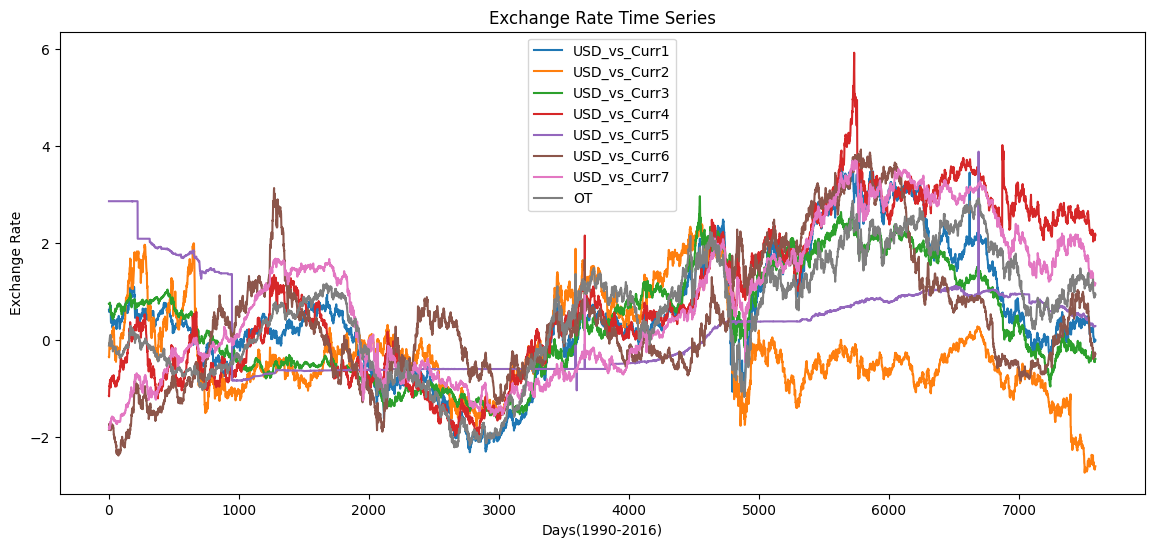

In [15]:
plt.figure(figsize=(14,6))
for col in df.columns[:-1]:
    plt.plot(df[col],label=col)
plt.legend()
plt.title("Exchange Rate Time Series")
plt.xlabel("Days(1990-2016)")
plt.ylabel("Exchange Rate")
plt.show()

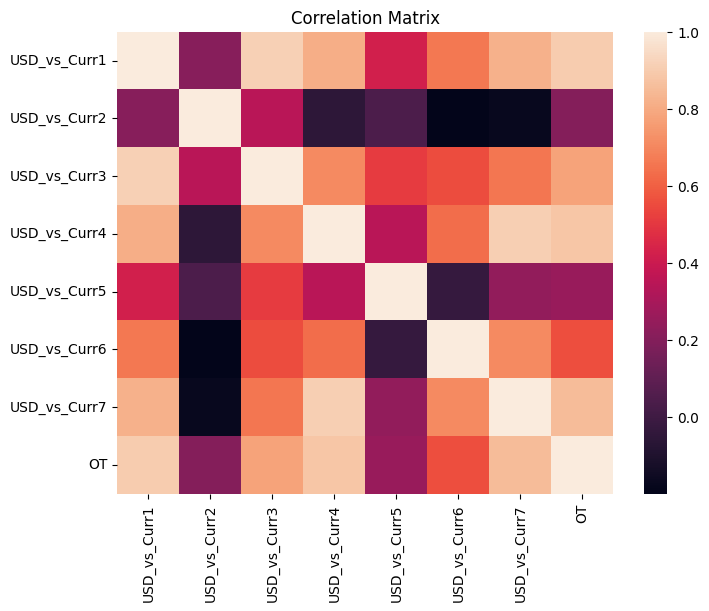

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["timestamp_idx"]).corr(), annot=False)
plt.title("Correlation Matrix")
plt.show()


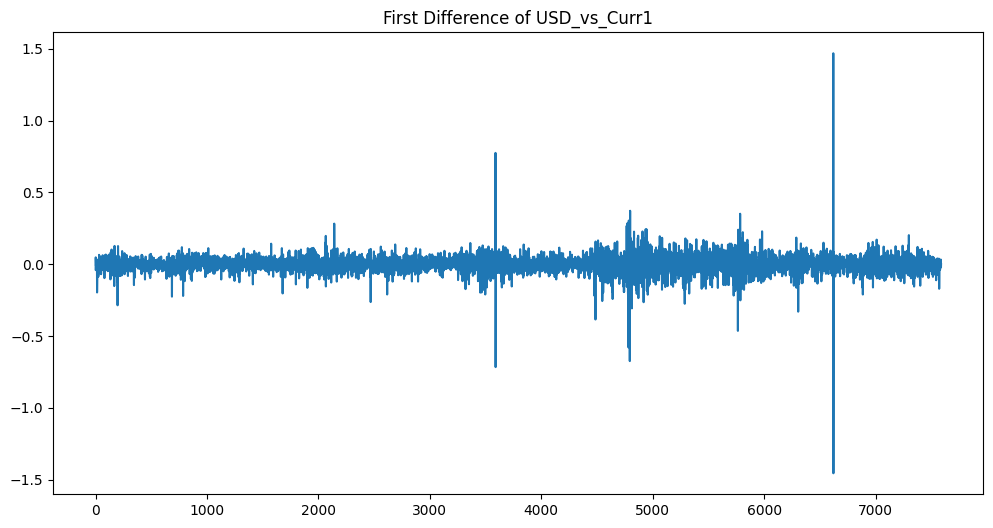

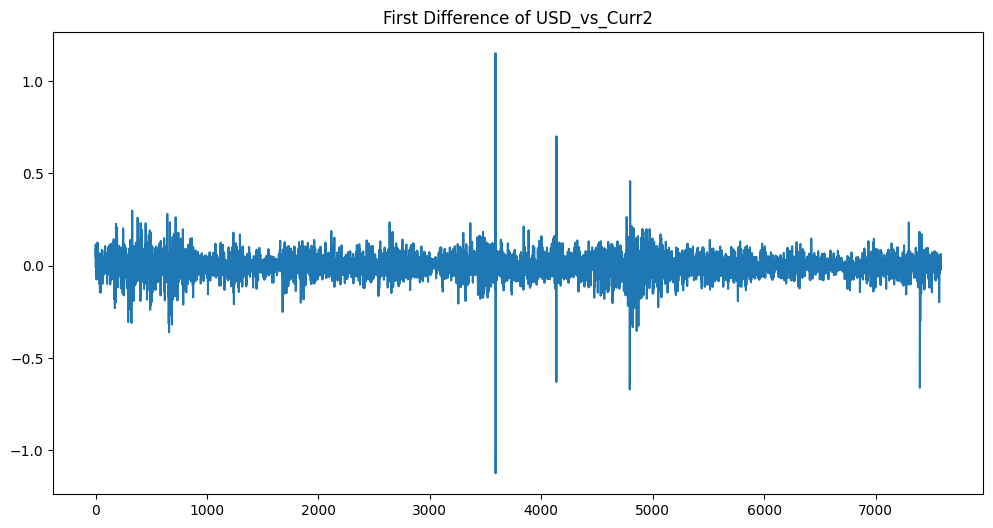

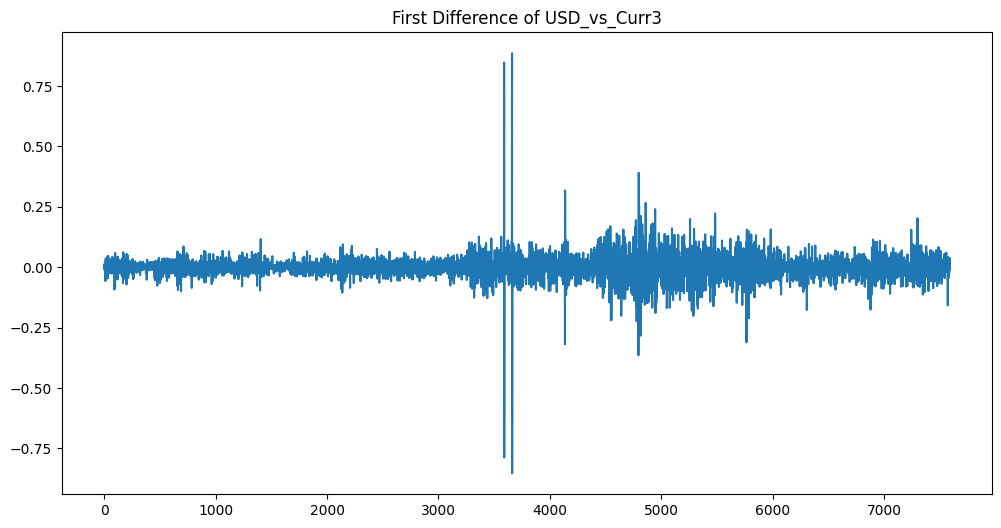

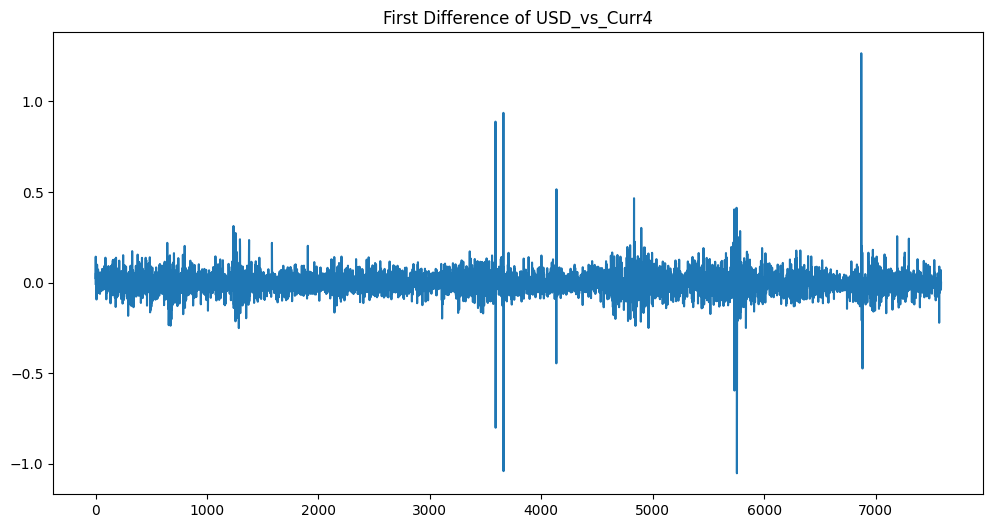

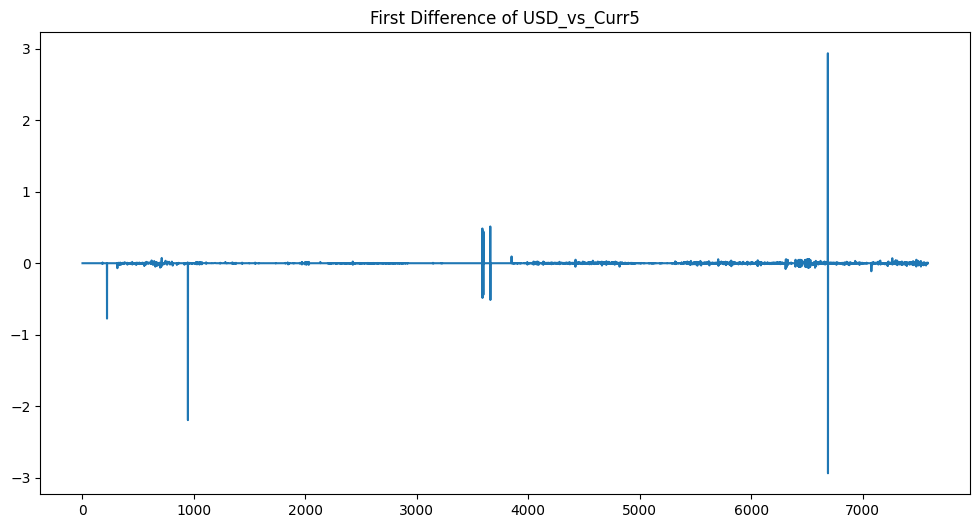

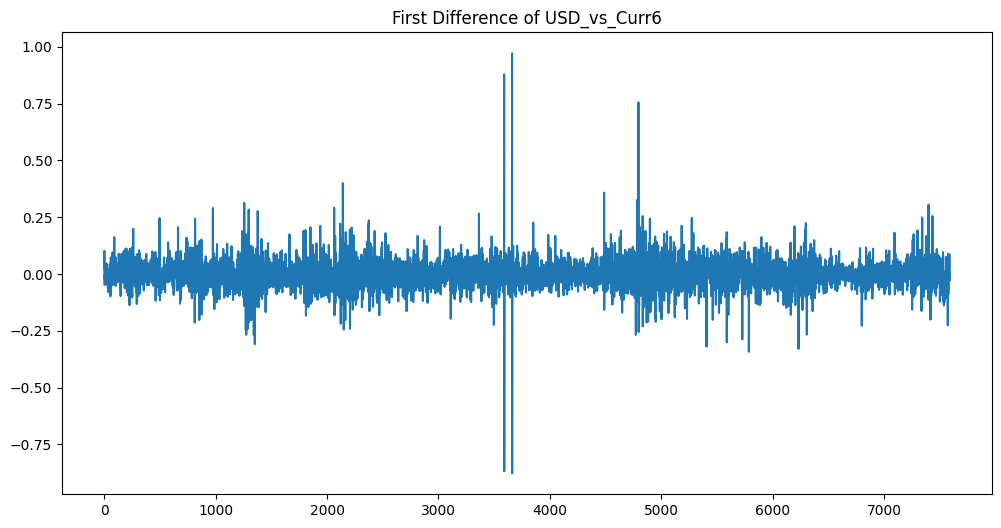

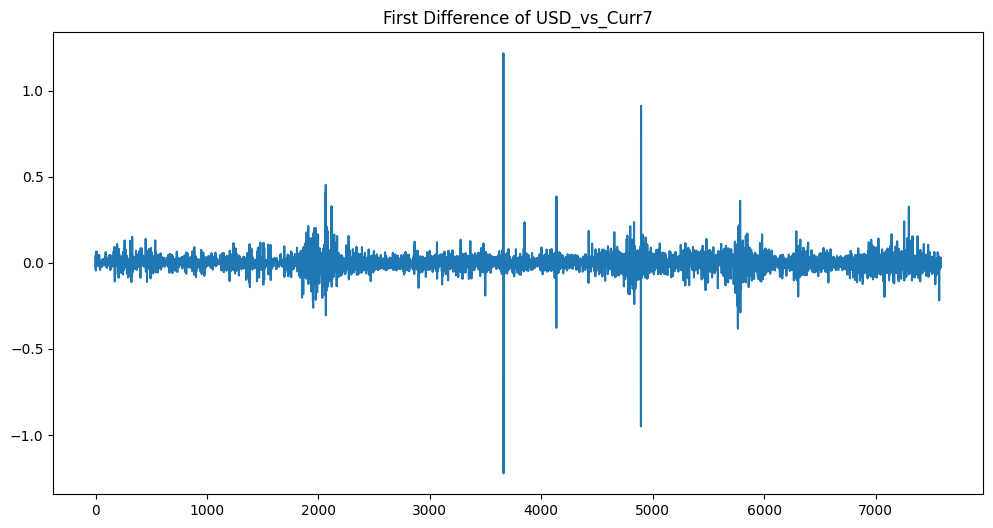

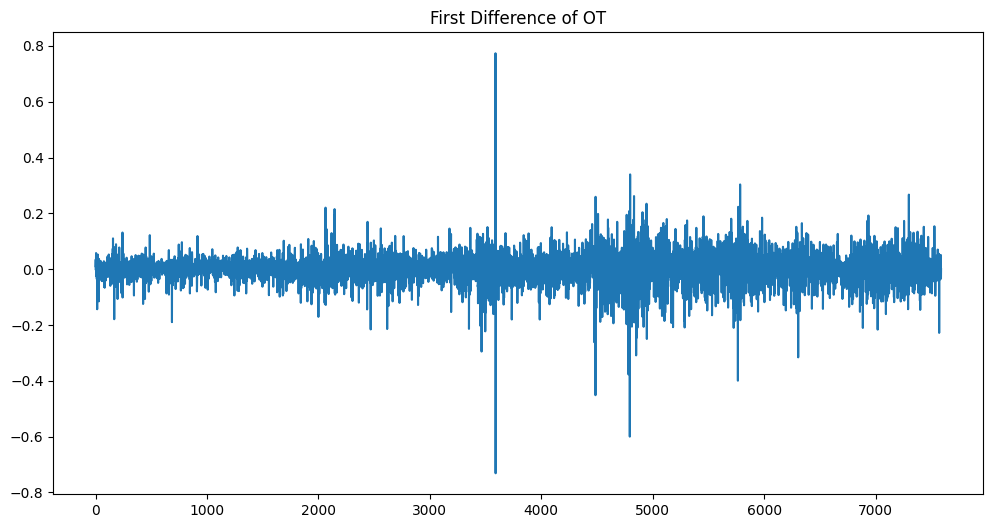

In [24]:

def plot_diff(col):
    df_diff = df.diff().dropna()

    plt.figure(figsize=(12,6))
    plt.plot(df_diff[col])
    plt.title(f"First Difference of {col}")
    plt.show()
for col in df:
    if(col!="timestamp_idx"):
        plot_diff(col)

In [18]:
%pip install statsmodels
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["USD_vs_Curr1"])
print("ADF p-value:", result[1])



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ADF p-value: 0.4492327064961482


### p-value>0.05 hence the data is not stationary

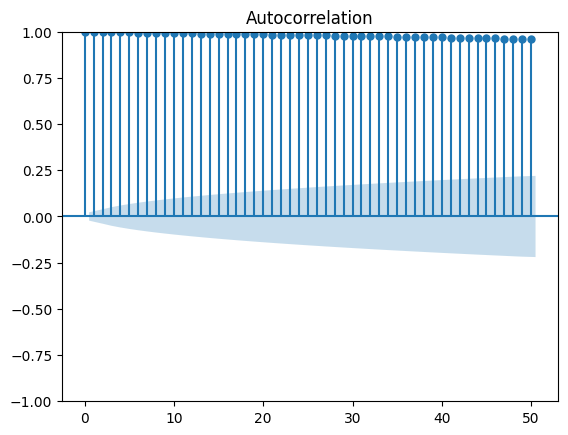

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["USD_vs_Curr1"], lags=50)
plt.show()


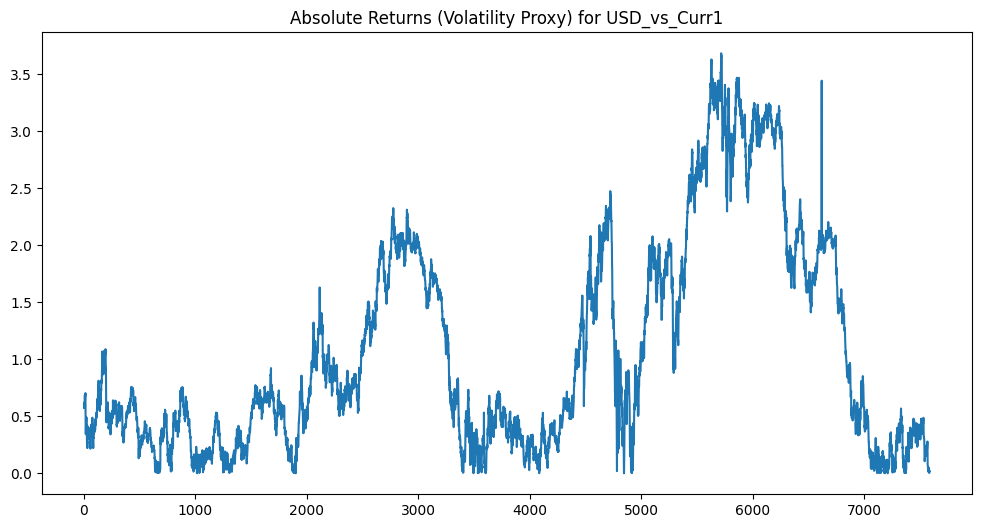

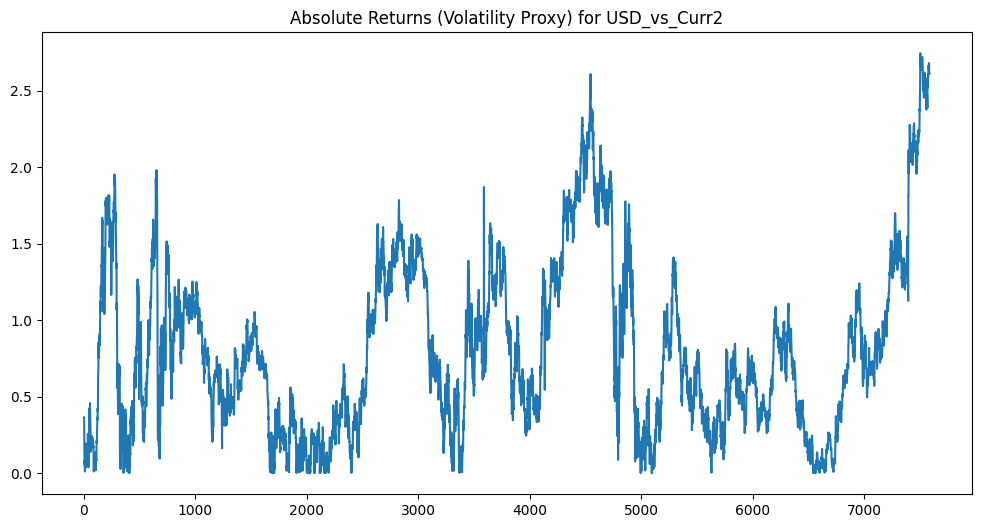

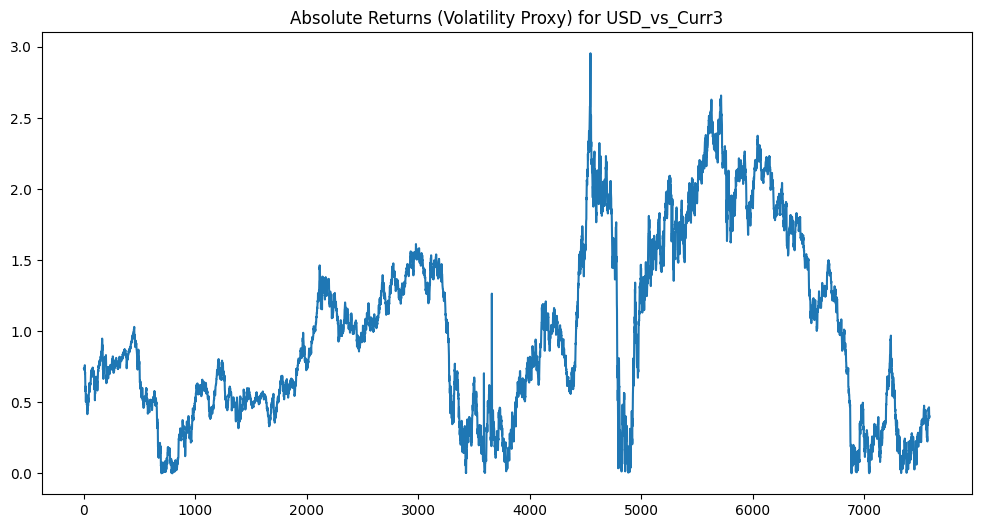

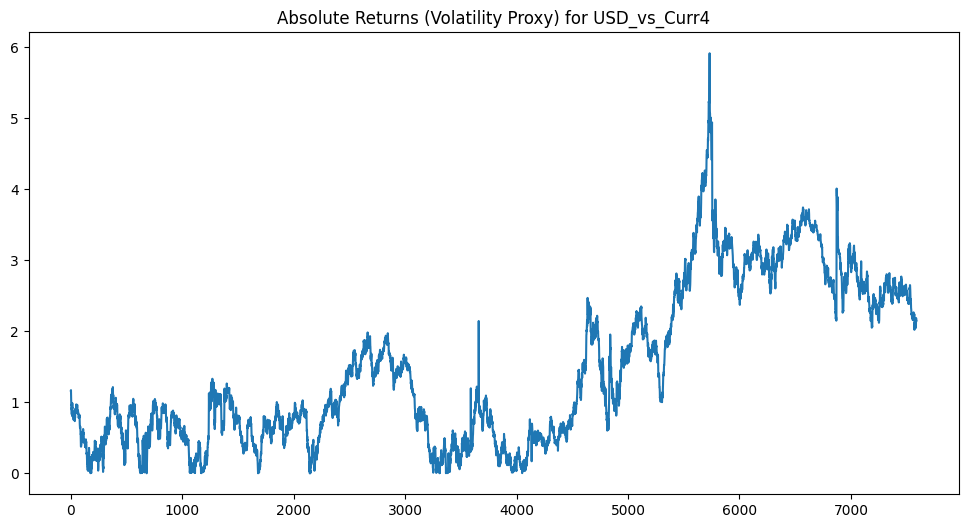

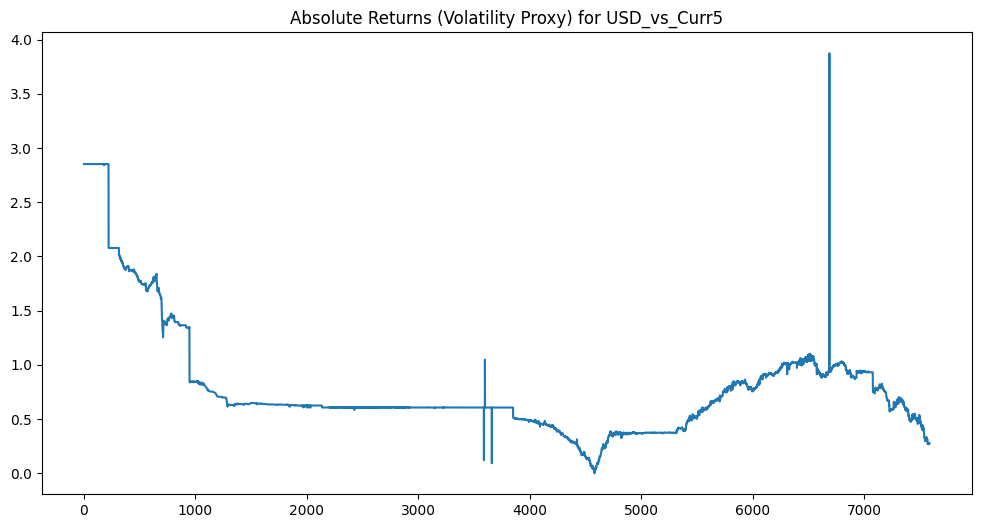

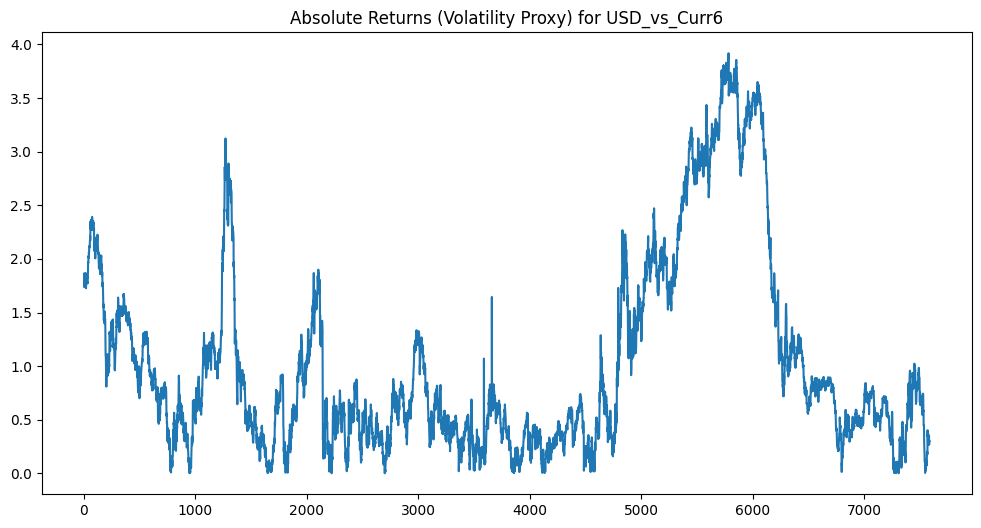

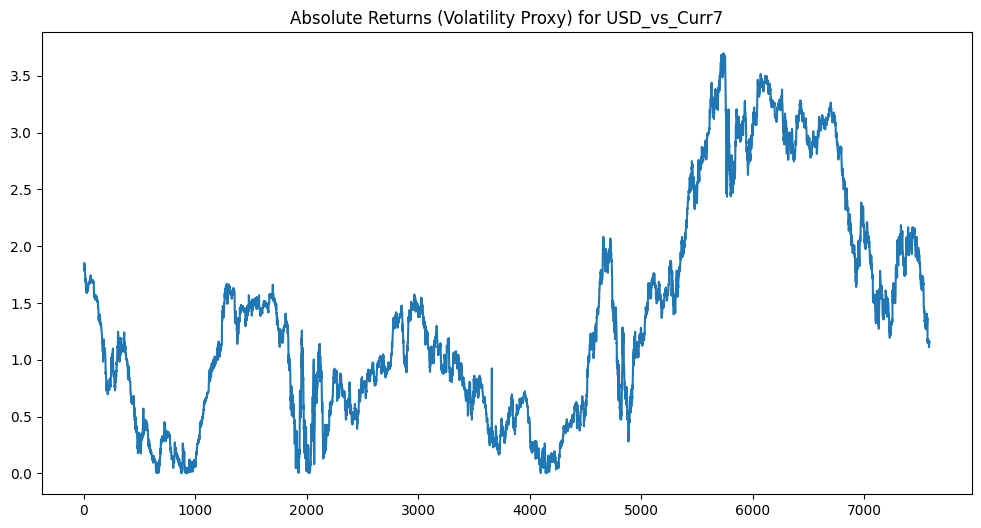

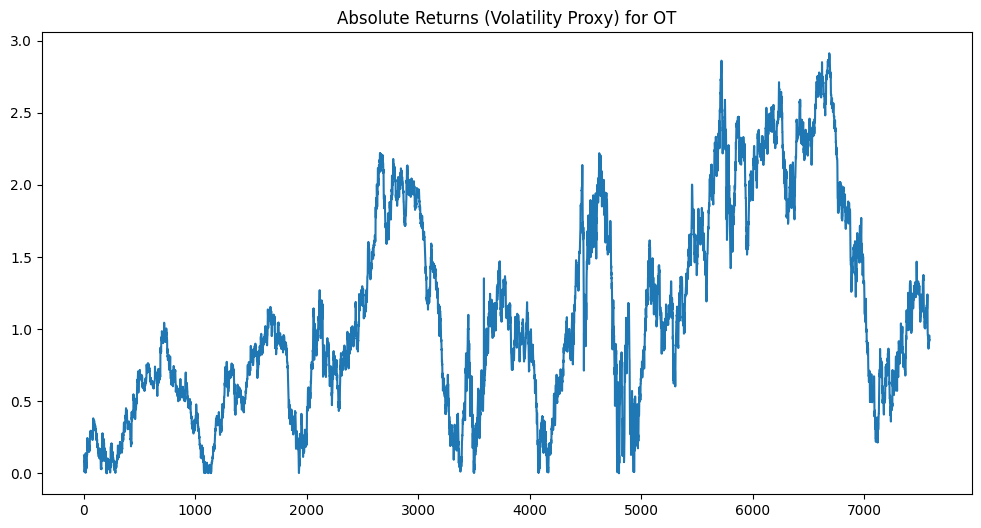

In [23]:
def abs_vol(col):
    plt.figure(figsize=(12,6))
    plt.plot(np.abs(df[col]))
    plt.title(f"Absolute Returns (Volatility Proxy) for {col}")
    plt.show()
for col in df:
    if(col!="timestamp_idx"):
        abs_vol(col)

In [27]:
df.to_csv("../data/raw/exchange_rate_combined.csv")
df_train.to_csv("../data/raw/train_data.csv")
df_test.to_csv("../data/raw/test_data.csv")
df_val.to_csv("../data/raw/validation_data.csv")